# Car Price Prediction - Final Project

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Tabulate for table-style output
from tabulate import tabulate

## Loading the Dataset

In [2]:
df = pd.read_csv(r"D:\My Files\02_Academic\Data Science\Projects\FINAL PROJECT\DataSet\cardekho.csv")
print('Dataset loaded successfully!')
print('Shape:', df.shape)

Dataset loaded successfully!
Shape: (8128, 12)


---
# Section 1: Exploratory Data Analysis (EDA)

## Basic Dataset Info

In [3]:
print('Rows:', df.shape[0], '| Columns:', df.shape[1])
print()
print('Column Names:')
print(df.columns.tolist())

Rows: 8128 | Columns: 12

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']


In [4]:
dtype_df = df.dtypes.reset_index()
dtype_df.columns = ['Column', 'Data Type']
print('\nData Types:')
print(tabulate(dtype_df, headers='keys', tablefmt='fancy_grid', showindex=False))


Data Types:
╒════════════════════╤═════════════╕
│ Column             │ Data Type   │
╞════════════════════╪═════════════╡
│ name               │ object      │
├────────────────────┼─────────────┤
│ year               │ int64       │
├────────────────────┼─────────────┤
│ selling_price      │ int64       │
├────────────────────┼─────────────┤
│ km_driven          │ int64       │
├────────────────────┼─────────────┤
│ fuel               │ object      │
├────────────────────┼─────────────┤
│ seller_type        │ object      │
├────────────────────┼─────────────┤
│ transmission       │ object      │
├────────────────────┼─────────────┤
│ owner              │ object      │
├────────────────────┼─────────────┤
│ mileage(km/ltr/kg) │ float64     │
├────────────────────┼─────────────┤
│ engine             │ float64     │
├────────────────────┼─────────────┤
│ max_power          │ object      │
├────────────────────┼─────────────┤
│ seats              │ float64     │
╘════════════════════╧═══

In [5]:
print('Head — First 5 Rows:')
print(tabulate(df.head(), headers='keys', tablefmt='fancy_grid', showindex=False))

Head — First 5 Rows:
╒══════════════════════════════╤════════╤═════════════════╤═════════════╤════════╤═══════════════╤════════════════╤══════════════╤══════════════════════╤══════════╤═════════════╤═════════╕
│ name                         │   year │   selling_price │   km_driven │ fuel   │ seller_type   │ transmission   │ owner        │   mileage(km/ltr/kg) │   engine │   max_power │   seats │
╞══════════════════════════════╪════════╪═════════════════╪═════════════╪════════╪═══════════════╪════════════════╪══════════════╪══════════════════════╪══════════╪═════════════╪═════════╡
│ Maruti Swift Dzire VDI       │   2014 │          450000 │      145500 │ Diesel │ Individual    │ Manual         │ First Owner  │                23.4  │     1248 │       74    │       5 │
├──────────────────────────────┼────────┼─────────────────┼─────────────┼────────┼───────────────┼────────────────┼──────────────┼──────────────────────┼──────────┼─────────────┼─────────┤
│ Skoda Rapid 1.5 TDI Ambition │  

In [6]:
print('Tail — Last 5 Rows:')
print(tabulate(df.tail(), headers='keys', tablefmt='fancy_grid', showindex=False))

Tail — Last 5 Rows:
╒════════════════════════╤════════╤═════════════════╤═════════════╤════════╤═══════════════╤════════════════╤══════════════════════╤══════════════════════╤══════════╤═════════════╤═════════╕
│ name                   │   year │   selling_price │   km_driven │ fuel   │ seller_type   │ transmission   │ owner                │   mileage(km/ltr/kg) │   engine │   max_power │   seats │
╞════════════════════════╪════════╪═════════════════╪═════════════╪════════╪═══════════════╪════════════════╪══════════════════════╪══════════════════════╪══════════╪═════════════╪═════════╡
│ Hyundai i20 Magna      │   2013 │          320000 │      110000 │ Petrol │ Individual    │ Manual         │ First Owner          │                18.5  │     1197 │       82.85 │       5 │
├────────────────────────┼────────┼─────────────────┼─────────────┼────────┼───────────────┼────────────────┼──────────────────────┼──────────────────────┼──────────┼─────────────┼─────────┤
│ Hyundai Verna CRDi SX  

In [7]:
print('Statistical Summary (describe):')
print(tabulate(df.describe().round(2), headers='keys', tablefmt='fancy_grid'))

Statistical Summary (describe):
╒═══════╤═════════╤═════════════════╤═════════════════╤══════════════════════╤══════════╤═════════╕
│       │    year │   selling_price │       km_driven │   mileage(km/ltr/kg) │   engine │   seats │
╞═══════╪═════════╪═════════════════╪═════════════════╪══════════════════════╪══════════╪═════════╡
│ count │ 8128    │        8128     │  8128           │              7907    │  7907    │ 7907    │
├───────┼─────────┼─────────────────┼─────────────────┼──────────────────────┼──────────┼─────────┤
│ mean  │ 2013.8  │      638272     │ 69819.5         │                19.42 │  1458.63 │    5.42 │
├───────┼─────────┼─────────────────┼─────────────────┼──────────────────────┼──────────┼─────────┤
│ std   │    4.04 │      806253     │ 56550.6         │                 4.04 │   503.92 │    0.96 │
├───────┼─────────┼─────────────────┼─────────────────┼──────────────────────┼──────────┼─────────┤
│ min   │ 1983    │       29999     │     1           │             

In [8]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)
print('Missing Values:')
print(tabulate(missing, headers='keys', tablefmt='fancy_grid', showindex=False))
print()
print('Duplicate Rows:', df.duplicated().sum())

Missing Values:
╒════════════════════╤═════════════════╤═════════════╕
│ Column             │   Missing Count │   Missing % │
╞════════════════════╪═════════════════╪═════════════╡
│ name               │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ year               │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ selling_price      │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ km_driven          │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ fuel               │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ seller_type        │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ transmission       │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ owner              │               0 │        0

---
## 6 Analytical Questions

### Q1: Which fuel type is most common in the dataset?

In [9]:
q1 = df['fuel'].value_counts().reset_index()
q1.columns = ['Fuel Type', 'Number of Cars']
q1['Percentage (%)'] = (q1['Number of Cars'] / q1['Number of Cars'].sum() * 100).round(2)
print(tabulate(q1, headers='keys', tablefmt='fancy_grid', showindex=False))

╒═════════════╤══════════════════╤══════════════════╕
│ Fuel Type   │   Number of Cars │   Percentage (%) │
╞═════════════╪══════════════════╪══════════════════╡
│ Diesel      │             4402 │            54.16 │
├─────────────┼──────────────────┼──────────────────┤
│ Petrol      │             3631 │            44.67 │
├─────────────┼──────────────────┼──────────────────┤
│ CNG         │               57 │             0.7  │
├─────────────┼──────────────────┼──────────────────┤
│ LPG         │               38 │             0.47 │
╘═════════════╧══════════════════╧══════════════════╛


### Q2: How does the manufacturing year affect the average selling price?

In [10]:
q2 = df.groupby('year')['selling_price'].mean().reset_index()
q2.columns = ['Year', 'Avg Selling Price (Rs)']
q2 = q2.sort_values('Year', ascending=False)
q2['Avg Selling Price (Rs)'] = q2['Avg Selling Price (Rs)'].round(0).astype(int)
print(tabulate(q2, headers='keys', tablefmt='fancy_grid', showindex=False))

╒════════╤══════════════════════════╕
│   Year │   Avg Selling Price (Rs) │
╞════════╪══════════════════════════╡
│   2020 │         885270           │
├────────┼──────────────────────────┤
│   2019 │              1.77699e+06 │
├────────┼──────────────────────────┤
│   2018 │         957769           │
├────────┼──────────────────────────┤
│   2017 │         889247           │
├────────┼──────────────────────────┤
│   2016 │         699880           │
├────────┼──────────────────────────┤
│   2015 │         596613           │
├────────┼──────────────────────────┤
│   2014 │         516193           │
├────────┼──────────────────────────┤
│   2013 │         460006           │
├────────┼──────────────────────────┤
│   2012 │         351164           │
├────────┼──────────────────────────┤
│   2011 │         323775           │
├────────┼──────────────────────────┤
│   2010 │         272622           │
├────────┼──────────────────────────┤
│   2009 │         226435           │
├────────┼──

### Q3: Manual vs Automatic — which transmission type is more common?

In [11]:
q3 = df['transmission'].value_counts().reset_index()
q3.columns = ['Transmission', 'Count']
q3['Percentage (%)'] = (q3['Count'] / q3['Count'].sum() * 100).round(2)
print(tabulate(q3, headers='keys', tablefmt='fancy_grid', showindex=False))

╒════════════════╤═════════╤══════════════════╕
│ Transmission   │   Count │   Percentage (%) │
╞════════════════╪═════════╪══════════════════╡
│ Manual         │    7078 │            87.08 │
├────────────────┼─────────┼──────────────────┤
│ Automatic      │    1050 │            12.92 │
╘════════════════╧═════════╧══════════════════╛


### Q4: Does higher km driven mean a lower selling price?

In [12]:
df['km_bucket'] = pd.cut(
    df['km_driven'],
    bins=[0, 30000, 60000, 100000, 200000, 10000000],
    labels=['0-30k', '30k-60k', '60k-100k', '100k-200k', '200k+']
)
q4 = df.groupby('km_bucket', observed=True)['selling_price'].mean().reset_index()
q4.columns = ['KM Range', 'Avg Selling Price (Rs)']
q4['Avg Selling Price (Rs)'] = q4['Avg Selling Price (Rs)'].round(0).astype(int)
print(tabulate(q4, headers='keys', tablefmt='fancy_grid', showindex=False))

╒════════════╤══════════════════════════╕
│ KM Range   │   Avg Selling Price (Rs) │
╞════════════╪══════════════════════════╡
│ 0-30k      │                  1101727 │
├────────────┼──────────────────────────┤
│ 30k-60k    │                   613896 │
├────────────┼──────────────────────────┤
│ 60k-100k   │                   454710 │
├────────────┼──────────────────────────┤
│ 100k-200k  │                   405907 │
├────────────┼──────────────────────────┤
│ 200k+      │                   426256 │
╘════════════╧══════════════════════════╛


### Q5: Dealer vs Individual — who has more cars listed?

In [13]:
q5 = df['seller_type'].value_counts().reset_index()
q5.columns = ['Seller Type', 'Count']
q5['Percentage (%)'] = (q5['Count'] / q5['Count'].sum() * 100).round(2)
print(tabulate(q5, headers='keys', tablefmt='fancy_grid', showindex=False))

╒══════════════════╤═════════╤══════════════════╕
│ Seller Type      │   Count │   Percentage (%) │
╞══════════════════╪═════════╪══════════════════╡
│ Individual       │    6766 │            83.24 │
├──────────────────┼─────────┼──────────────────┤
│ Dealer           │    1126 │            13.85 │
├──────────────────┼─────────┼──────────────────┤
│ Trustmark Dealer │     236 │             2.9  │
╘══════════════════╧═════════╧══════════════════╛


### Q6: What are the Top 10 most expensive cars by selling price?

In [14]:
q6 = df[['name','year','selling_price','fuel','transmission']].sort_values(
    'selling_price', ascending=False).head(10).reset_index(drop=True)
q6.index += 1
q6.columns = ['Car Name','Year','Selling Price (Rs)','Fuel','Transmission']
print(tabulate(q6, headers='keys', tablefmt='fancy_grid'))

╒════╤══════════════════════════════════╤════════╤══════════════════════╤════════╤════════════════╕
│    │ Car Name                         │   Year │   Selling Price (Rs) │ Fuel   │ Transmission   │
╞════╪══════════════════════════════════╪════════╪══════════════════════╪════════╪════════════════╡
│  1 │ Volvo XC90 T8 Excellence BSIV    │   2017 │             10000000 │ Petrol │ Automatic      │
├────┼──────────────────────────────────┼────────┼──────────────────────┼────────┼────────────────┤
│  2 │ BMW X7 xDrive 30d DPE            │   2020 │              7200000 │ Diesel │ Automatic      │
├────┼──────────────────────────────────┼────────┼──────────────────────┼────────┼────────────────┤
│  3 │ Audi A6 35 TFSI Matrix           │   2019 │              6523000 │ Petrol │ Automatic      │
├────┼──────────────────────────────────┼────────┼──────────────────────┼────────┼────────────────┤
│  4 │ Audi A6 35 TFSI Matrix           │   2019 │              6223000 │ Petrol │ Automatic      │


---
## Graphical Representation
### Graph 1 — Q1: Fuel Type Distribution (Bar Chart)

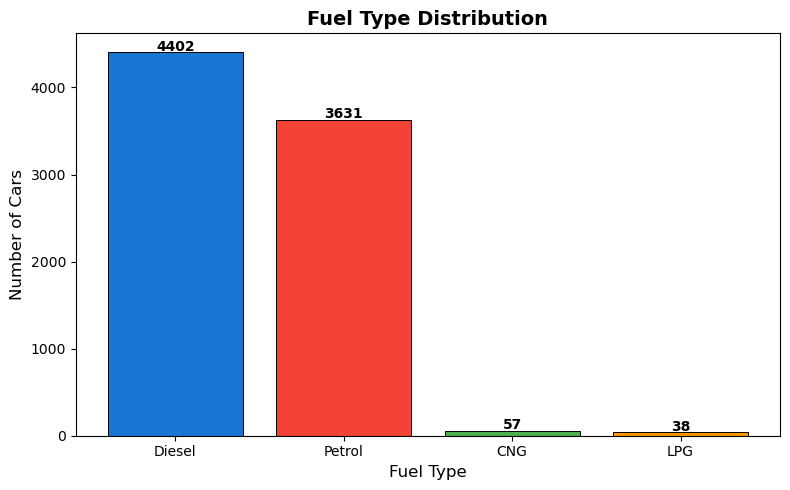

In [15]:
fuel_counts = df['fuel'].value_counts()
bar_colors = ['#1976D2','#F44336','#4CAF50','#FF9800','#9C27B0']

plt.figure(figsize=(8, 5))
bars = plt.bar(fuel_counts.index, fuel_counts.values,
               color=bar_colors[:len(fuel_counts)], edgecolor='black', linewidth=0.7)
plt.title('Fuel Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 15,
             str(int(bar.get_height())),
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Graph 2 — Q2: Year vs Average Selling Price (Line Chart)

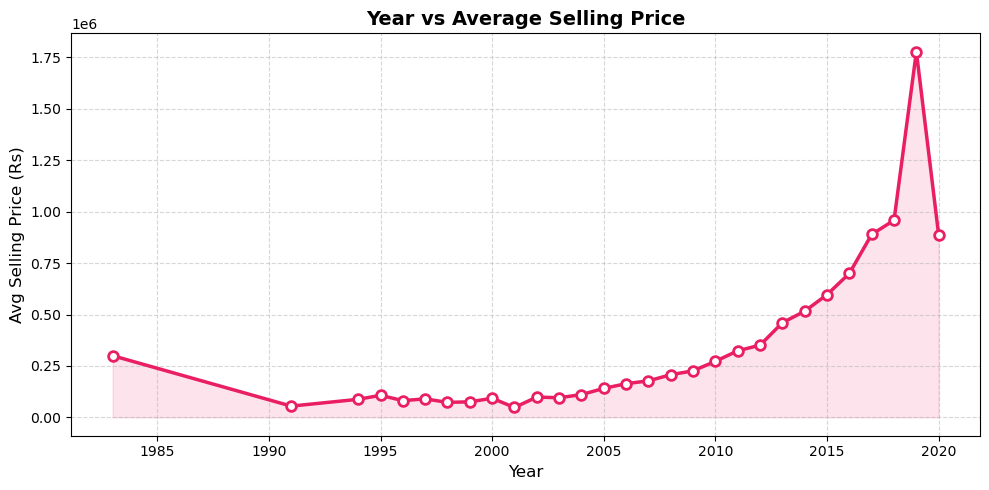

In [16]:
year_price = df.groupby('year')['selling_price'].mean().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(year_price.index, year_price.values,
         marker='o', color='#E91E63', linewidth=2.5,
         markersize=7, markerfacecolor='white',
         markeredgecolor='#E91E63', markeredgewidth=2)
plt.fill_between(year_price.index, year_price.values, alpha=0.12, color='#E91E63')
plt.title('Year vs Average Selling Price', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Avg Selling Price (Rs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Graph 3 — Q4: Kms Driven vs Selling Price (Scatter Plot)

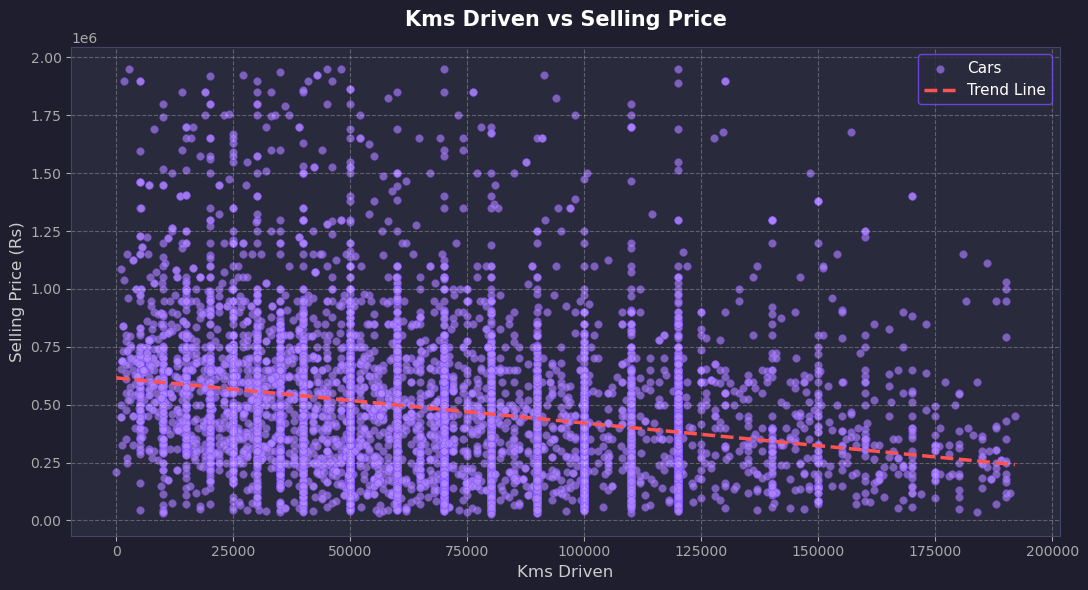

In [17]:
Q1_km  = df['km_driven'].quantile(0.25)
Q3_km  = df['km_driven'].quantile(0.75)
IQR_km = Q3_km - Q1_km
km_upper = Q3_km + 1.5 * IQR_km
sp_upper = df['selling_price'].quantile(0.95)

df_plot = df[(df['km_driven'] <= km_upper) & (df['selling_price'] <= sp_upper)]

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#2a2a3d')

ax.scatter(df_plot['km_driven'], df_plot['selling_price'],
           alpha=0.6,
           color='#b388ff',
           s=30,
           edgecolors='#7c4dff',
           linewidths=0.5,
           label='Cars')

z = np.polyfit(df_plot['km_driven'], df_plot['selling_price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_plot['km_driven'].min(), df_plot['km_driven'].max(), 200)
ax.plot(x_line, p(x_line),
        color='#ff5252',
        linewidth=2.5,
        linestyle='--',
        label='Trend Line')

ax.set_title('Kms Driven vs Selling Price', fontsize=15,
             fontweight='bold', color='white', pad=15)
ax.set_xlabel('Kms Driven', fontsize=12, color='#cccccc')
ax.set_ylabel('Selling Price (Rs)', fontsize=12, color='#cccccc')

ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#444466')

ax.grid(True, linestyle='--', alpha=0.25, color='white')

legend = ax.legend(fontsize=11, facecolor='#2a2a3d',
                   edgecolor='#7c4dff', labelcolor='white')
plt.tight_layout()
plt.show()

---
# Section 2: Preprocessing

## Drop temporary columns & handle Missing Values

In [18]:
# Drop the km_bucket column we made earlier
df.drop(columns=['km_bucket'], inplace=True, errors='ignore')

print('Missing values before drop:')
mv = df.isnull().sum().reset_index()
mv.columns = ['Column','Missing Count']
mv['Missing %'] = (mv['Missing Count'] / len(df) * 100).round(2)
print(tabulate(mv, headers='keys', tablefmt='fancy_grid', showindex=False))

df.dropna(inplace=True)
print('\nAfter dropping nulls — Shape:', df.shape)

Missing values before drop:
╒════════════════════╤═════════════════╤═════════════╕
│ Column             │   Missing Count │   Missing % │
╞════════════════════╪═════════════════╪═════════════╡
│ name               │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ year               │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ selling_price      │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ km_driven          │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ fuel               │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ seller_type        │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ transmission       │               0 │        0    │
├────────────────────┼─────────────────┼─────────────┤
│ owner              │               

## Remove Duplicate Rows

In [19]:
print('Duplicates found:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('After removing duplicates — Shape:', df.shape)

Duplicates found: 1189
After removing duplicates — Shape: (6718, 12)


## Clean Mixed Columns (mileage, engine, max_power)

In [20]:
# These columns have units attached like '18.5 kmpl' or '1197 CC'
def extract_number(val):
    try:
        return float(str(val).split()[0])
    except:
        return np.nan

for col in ['mileage', 'engine', 'max_power']:
    if col in df.columns:
        df[col] = df[col].apply(extract_number)

# Torque column has complex units — dropping it
if 'torque' in df.columns:
    df.drop(columns=['torque'], inplace=True)

# Name column has too many unique values — not useful for ML
if 'name' in df.columns:
    df.drop(columns=['name'], inplace=True)

# Drop any NaN created during extraction
df.dropna(inplace=True)
print('After cleaning — Shape:', df.shape)
print(tabulate(df.head(3), headers='keys', tablefmt='fancy_grid', showindex=False))

After cleaning — Shape: (6717, 11)
╒════════╤═════════════════╤═════════════╤════════╤═══════════════╤════════════════╤══════════════╤══════════════════════╤══════════╤═════════════╤═════════╕
│   year │   selling_price │   km_driven │ fuel   │ seller_type   │ transmission   │ owner        │   mileage(km/ltr/kg) │   engine │   max_power │   seats │
╞════════╪═════════════════╪═════════════╪════════╪═══════════════╪════════════════╪══════════════╪══════════════════════╪══════════╪═════════════╪═════════╡
│   2014 │          450000 │      145500 │ Diesel │ Individual    │ Manual         │ First Owner  │                23.4  │     1248 │       74    │       5 │
├────────┼─────────────────┼─────────────┼────────┼───────────────┼────────────────┼──────────────┼──────────────────────┼──────────┼─────────────┼─────────┤
│   2014 │          370000 │      120000 │ Diesel │ Individual    │ Manual         │ Second Owner │                21.14 │     1498 │      103.52 │       5 │
├────────┼───────

## Label Encoding (Categorical Columns)

In [21]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
le = LabelEncoder()
info = []

for col in cat_cols:
    if col in df.columns:
        original = df[col].unique().tolist()
        df[col] = le.fit_transform(df[col])
        info.append({'Column': col, 'Original': str(original)})

print('Encoding done:')
print(tabulate(info, headers='keys', tablefmt='fancy_grid', showindex=False))

Encoding done:
╒══════════════╤══════════════════════════════════════════════════════════════════════════════════════════╕
│ Column       │ Original                                                                                 │
╞══════════════╪══════════════════════════════════════════════════════════════════════════════════════════╡
│ fuel         │ ['Diesel', 'Petrol', 'LPG', 'CNG']                                                       │
├──────────────┼──────────────────────────────────────────────────────────────────────────────────────────┤
│ seller_type  │ ['Individual', 'Dealer', 'Trustmark Dealer']                                             │
├──────────────┼──────────────────────────────────────────────────────────────────────────────────────────┤
│ transmission │ ['Manual', 'Automatic']                                                                  │
├──────────────┼──────────────────────────────────────────────────────────────────────────────────────────┤
│ owner      

## Outlier Removal (IQR Method)

In [22]:
Q1_val = df['selling_price'].quantile(0.25)
Q3_val = df['selling_price'].quantile(0.75)
IQR = Q3_val - Q1_val
lower = Q1_val - 1.5 * IQR
upper = Q3_val + 1.5 * IQR

before = len(df)
df = df[(df['selling_price'] >= lower) & (df['selling_price'] <= upper)]
after = len(df)

summary = [
    {'Metric': 'Q1',              'Value': round(Q1_val, 2)},
    {'Metric': 'Q3',              'Value': round(Q3_val, 2)},
    {'Metric': 'IQR',             'Value': round(IQR, 2)},
    {'Metric': 'Lower Bound',     'Value': round(lower, 2)},
    {'Metric': 'Upper Bound',     'Value': round(upper, 2)},
    {'Metric': 'Rows Before',     'Value': before},
    {'Metric': 'Rows After',      'Value': after},
    {'Metric': 'Outliers Removed','Value': before - after},
]
print(tabulate(summary, headers='keys', tablefmt='fancy_grid', showindex=False))

╒══════════════════╤════════════════╕
│ Metric           │          Value │
╞══════════════════╪════════════════╡
│ Q1               │  250000        │
├──────────────────┼────────────────┤
│ Q3               │  650000        │
├──────────────────┼────────────────┤
│ IQR              │  400000        │
├──────────────────┼────────────────┤
│ Lower Bound      │ -350000        │
├──────────────────┼────────────────┤
│ Upper Bound      │       1.25e+06 │
├──────────────────┼────────────────┤
│ Rows Before      │    6717        │
├──────────────────┼────────────────┤
│ Rows After       │    6411        │
├──────────────────┼────────────────┤
│ Outliers Removed │     306        │
╘══════════════════╧════════════════╛


---
# Section 3: ML Training
Using **Random Forest Regressor**.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

X = df.drop(columns=['selling_price'])
y = df['selling_price']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 5128
Testing samples : 1283


In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print('Model training done!')

Model training done!


In [25]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

metrics = [
    {'Metric': 'MAE  (Mean Absolute Error)',     'Value': f'Rs {mae:,.0f}'},
    {'Metric': 'RMSE (Root Mean Squared Error)', 'Value': f'Rs {rmse:,.0f}'},
    {'Metric': 'R2 Score',                       'Value': f'{r2:.4f} ({r2*100:.2f}%)'},
]
print('Model Performance:')
print(tabulate(metrics, headers='keys', tablefmt='fancy_grid', showindex=False))

Model Performance:
╒════════════════════════════════╤═════════════════╕
│ Metric                         │ Value           │
╞════════════════════════════════╪═════════════════╡
│ MAE  (Mean Absolute Error)     │ Rs 61,166       │
├────────────────────────────────┼─────────────────┤
│ RMSE (Root Mean Squared Error) │ Rs 86,038       │
├────────────────────────────────┼─────────────────┤
│ R2 Score                       │ 0.8904 (89.04%) │
╘════════════════════════════════╧═════════════════╛


In [26]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).round(4)

print('Feature Importance:')
print(tabulate(feat_imp, headers='keys', tablefmt='fancy_grid', showindex=False))

Feature Importance:
╒════════════════════╤══════════════╕
│ Feature            │   Importance │
╞════════════════════╪══════════════╡
│ year               │       0.4321 │
├────────────────────┼──────────────┤
│ max_power          │       0.328  │
├────────────────────┼──────────────┤
│ engine             │       0.1167 │
├────────────────────┼──────────────┤
│ mileage(km/ltr/kg) │       0.0484 │
├────────────────────┼──────────────┤
│ km_driven          │       0.0453 │
├────────────────────┼──────────────┤
│ owner              │       0.009  │
├────────────────────┼──────────────┤
│ seats              │       0.008  │
├────────────────────┼──────────────┤
│ fuel               │       0.0059 │
├────────────────────┼──────────────┤
│ seller_type        │       0.0035 │
├────────────────────┼──────────────┤
│ transmission       │       0.003  │
╘════════════════════╧══════════════╛


In [27]:
sample = pd.DataFrame({
    'Actual Price (Rs)':    y_test.values[:5],
    'Predicted Price (Rs)': y_pred[:5].round(0).astype(int)
})
print('Sample Predictions (first 5):')
print(tabulate(sample, headers='keys', tablefmt='fancy_grid', showindex=False))

Sample Predictions (first 5):
╒═════════════════════╤════════════════════════╕
│   Actual Price (Rs) │   Predicted Price (Rs) │
╞═════════════════════╪════════════════════════╡
│              350000 │                 484420 │
├─────────────────────┼────────────────────────┤
│              800000 │                 753760 │
├─────────────────────┼────────────────────────┤
│              346000 │                 389960 │
├─────────────────────┼────────────────────────┤
│              110000 │                 248260 │
├─────────────────────┼────────────────────────┤
│              475000 │                 469120 │
╘═════════════════════╧════════════════════════╛


In [28]:
with open('car_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print('Model saved as car_price_model.pkl')
print('Columns saved as model_columns.pkl')

Model saved as car_price_model.pkl
Columns saved as model_columns.pkl


---
# Section 4: CLI Application

In [29]:
import pickle

def predict_car_price():
    print('=' * 50)
    print('     CAR PRICE PREDICTION - CLI APP')
    print('=' * 50)

    with open('car_price_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
    with open('model_columns.pkl', 'rb') as f:
        columns = pickle.load(f)

    print('Enter car details below:')

    try:
        year         = int(float(input('Year              (e.g. 2018)         : ')))
        km_driven    = float(input('Kms Driven        (e.g. 45000)         : '))
        fuel         = int(input('Fuel Type         (0=CNG 1=Diesel 2=Electric 3=LPG 4=Petrol): '))
        seller_type  = int(input('Seller Type       (0=Dealer 1=Individual 2=Trustmark)       : '))
        transmission = int(input('Transmission      (0=Automatic 1=Manual)                   : '))
        owner        = int(input('Owner             (0=First 1=Second 2=Third 3=Fourth+)      : '))
        mileage      = float(input('Mileage (kmpl)    (e.g. 18.5)           : '))
        engine       = float(input('Engine (CC)       (e.g. 1197)           : '))
        max_power    = float(input('Max Power (bhp)   (e.g. 82.0)           : '))
        seats        = float(input('Seats             (e.g. 5)              : '))

        input_data = pd.DataFrame(
            [[year, km_driven, fuel, seller_type, transmission,
              owner, mileage, engine, max_power, seats]],
            columns=columns
        )

        price = loaded_model.predict(input_data)[0]
        print('=' * 50)
        print(f'  Predicted Car Price : Rs {price:,.0f}')
        print('=' * 50)

    except ValueError as e:
        print(f'Input error: {e}')


while True:
    predict_car_price()
    again = input('\nPredict another car? (yes / no): ').strip().lower()
    if again != 'yes':
        print('Closing app...')
        break

     CAR PRICE PREDICTION - CLI APP
Enter car details below:


Year              (e.g. 2018)         :  2026
Kms Driven        (e.g. 45000)         :  50000
Fuel Type         (0=CNG 1=Diesel 2=Electric 3=LPG 4=Petrol):  4
Seller Type       (0=Dealer 1=Individual 2=Trustmark)       :  0
Transmission      (0=Automatic 1=Manual)                   :  1
Owner             (0=First 1=Second 2=Third 3=Fourth+)      :  0
Mileage (kmpl)    (e.g. 18.5)           :  20
Engine (CC)       (e.g. 1197)           :  5000
Max Power (bhp)   (e.g. 82.0)           :  100
Seats             (e.g. 5)              :  2


  Predicted Car Price : Rs 657,690



Predict another car? (yes / no):  no


Closing app...
